In [2]:
import polars as pl
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc, average_precision_score
from sklearn.model_selection import PredefinedSplit, GridSearchCV, RandomizedSearchCV
import xgboost as xgb
import lightgbm as lgb
import plotly.express as px
import joblib
# path = "/home/jovyan/work/"
path = "/home/diego/BigData/financial-fraud-MLOps/"

In [3]:
features_df = (
    pl.scan_parquet(f"{path}data/gold/Polars/feature_complete_fraud_data.parquet")
    .select(pl.all().exclude("client_id", "card_id", "date", 
                             # "id", 
                             "merchant_latitude", "merchant_longitude"
                            ))
)

features_df.show(5)

id,target,agemonth_at_event,days_acct_open,days_expires,retirement_years,No_Errors,Bad_Card_Number,Bad_CVV,Bad_Expiration,Bad_PIN,Bad_Zipcode,Insufficient_Balance,Technical_Glitch,Visa,Discover,Amex,Mastercard,Debit_Prepaid,Credit,Debit,Online_Transaction,Chip_Transaction,Swipe_Transaction,Male,Log2_risk_factor,amount,credit_limit,yearly_income,total_debt,sum_amount_24h,mean_log_amount_7d,stddev_log_amount_7d,sum_amount_7d,is_refund,aceleration_ratio_24h_vs_7d,ratio_24_credit_limit,…,is_tdiffm_in_IC95,is_tdiffm_in_IC99,hour_of_day,theta,sin_theta,cos_theta,N_7d,day_of_week,weekend,mu_vM_7d,sigma_vM_7d,ic_lower_vm_90_7d,ic_upper_vm_90_7d,ic_lower_vm_95_7d,ic_upper_vm_95_7d,ic_lower_vm_99_7d,ic_upper_vm_99_7d,is_time_in_IC_90,is_time_in_IC_95,is_time_in_IC_99,log_time_diff_m,mean_time_diff_m,stddev_time_diff_m,ic_lower_tdiffm_90,ic_upper_tdiffm_90,ic_lower_tdiffm_95,ic_upper_tdiffm_95,ic_lower_tdiffm_99,ic_upper_tdiffm_99,is_tdiffm_in_IC90_right,is_tdiffm_in_IC95_right,is_tdiffm_in_IC99_right,aceleration_ratio_24h_vs_7d_is_inf,ratio_24_credit_limit_is_inf,ratio_24_total_debt_is_inf,speed_km_s_is_inf,mean_speed_km_s_is_inf
str,bool,i64,i64,i64,i64,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,f64,f64,…,bool,bool,f64,f64,f64,f64,u32,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool,bool,bool,bool,bool,bool,bool,bool
"""13047138""",false,328,899,2812,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,false,false,true,true,0.5,42.52,31490.0,59613.0,36199.0,52.38,3.660233,0.861347,562.84,false,0.093064,0.001663,…,true,true,13.383333,-2.779437,-0.354291,-0.935135,14,5,true,-1.663538,1.198727,-2.230898,-1.096179,-2.355663,-0.971414,-2.628591,-0.698486,false,false,false,7.248504,5.526262,1.964124,4.596639,6.455886,4.392211,6.660314,3.945016,7.107509,false,false,false,false,false,false,false,false
"""13048785""",false,328,899,2812,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,false,false,true,true,-0.18,37.51,31490.0,59613.0,36199.0,52.79,3.667118,0.831563,605.25,false,0.08722,0.001676,…,true,true,20.583333,-0.894481,-0.779884,0.625923,15,5,true,-1.777568,1.205201,-2.325655,-1.22948,-2.444986,-1.110149,-2.703907,-0.851229,false,false,true,2.833213,5.643853,1.944779,4.759429,6.528277,4.566871,6.720836,4.149062,7.138644,false,false,false,false,false,false,false,false
"""13051758""",false,328,900,2811,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,false,false,true,true,2.45,44.17,31490.0,59613.0,36199.0,90.3,3.641438,0.859551,551.63,false,0.163697,0.002868,…,true,true,13.3,-2.801253,-0.333807,-0.942641,14,6,true,-1.651931,1.195052,-2.217551,-1.08631,-2.341933,-0.961928,-2.614025,-0.689837,false,false,false,6.911747,5.48505,2.067322,4.506582,6.463517,4.291413,6.678686,3.820722,7.149377,false,false,true,false,false,false,false,false
"""13063377""",false,328,903,2808,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,false,false,true,true,-3.73,14.5,31490.0,59613.0,36199.0,47.47,3.814873,0.60868,434.15,false,0.10934,0.001507,…,true,true,6.7,1.754056,0.983255,-0.182236,11,2,false,-2.445773,1.100984,-3.047436,-1.84411,3.097761,-1.706122,2.785344,-1.393704,false,false,false,6.957497,5.535058,2.399648,4.223704,6.846412,3.922953,7.147164,3.242022,7.828094,false,true,true,false,false,false,false,false
"""13065451""",false,328,903,2808,500,true,false,false,false,false,false,false,false,false,false,false,true,false,false,true,true,false,false,true,-0.81,16.73,31490.0,59613.0,36199.0,14.5,3.70915,0.687576,400.06,false,0.036245,0.00046,…,true,true,14.25,-2.552544,-0.55557,-0.83147,11,2,false,-2.56345,1.320764,2.997968,-1.841682,2.832434,-1.676148,2.457651,-1.301365,true,true,true,6.118097,5.548354,2.407817,4.232536,6.864172,3.93076,7.165948,3.247512,7.84

In [4]:
df = features_df.collect()

In [4]:
proportions = df.group_by("target").agg([
    pl.len().alias("cantidad"),
    (pl.len() / len(df) * 100).alias("porcentaje")
])

print(proportions)

shape: (2, 3)
┌────────┬──────────┬────────────┐
│ target ┆ cantidad ┆ porcentaje │
│ ---    ┆ ---      ┆ ---        │
│ bool   ┆ u32      ┆ f64        │
╞════════╪══════════╪════════════╡
│ false  ┆ 3112100  ┆ 99.706082  │
│ true   ┆ 9174     ┆ 0.293918   │
└────────┴──────────┴────────────┘


In [5]:
False_df = df.filter(~pl.col("target"))
False_train_df = False_df.sample(fraction=0.70, seed=777)
False_valtest_df = False_df.join(False_train_df, on="id", how="anti")
False_val_df = False_valtest_df.sample(fraction=0.50, seed=777)
False_test_df = False_valtest_df.join(False_val_df, on="id", how="anti")

True_df = df.filter(pl.col("target"))
True_train_df = True_df.sample(fraction=0.70, seed=777)
True_valtest_df = True_df.join(True_train_df, on="id", how="anti")
True_val_df = True_valtest_df.sample(fraction=0.50, seed=777)
True_test_df = True_valtest_df.join(True_val_df, on="id", how="anti")

## Tomaremos solo 100_000 transaciones legitimas para el entrenamiento ya que hay un alto desbalance entre
## las transacciones legítimas y las fraudulentas
balanced_False_train_df = False_train_df.sample(n=100_000, seed=777)

train_df = pl.concat([balanced_False_train_df, True_train_df]).sample(fraction=1.0, shuffle=True, seed=777)
val_df = pl.concat([False_val_df, True_val_df]).sample(fraction=1.0, shuffle=True, seed=777)
test_df = pl.concat([False_test_df, True_test_df]).sample(fraction=1.0, shuffle=True, seed=777)


## Definimos los datos que usaremos para el entrenamiento, la validación, el testeo del modelo
## y la búsqueda de hiperparámetros
X_train = train_df.drop("target", "id")
y_train = train_df["target"].cast(pl.Int8).to_numpy()

X_val = val_df.drop("target", "id")
y_val = val_df["target"].cast(pl.Int8).to_numpy()

X_test = test_df.drop("target", "id")
y_test = test_df["target"].cast(pl.Int8).to_numpy()

X_search = pl.concat([X_train, X_val])
y_search = np.concatenate((y_train, y_val))

split_indices = np.zeros(len(X_search))
split_indices[:len(X_train)] = -1  
split_indices[len(X_train):] = 0   
pds = PredefinedSplit(test_fold=split_indices)

threshold = 0.45

Definimos una función para graficar la curva PR-AUC

In [6]:
def plot_PRAUC(precision, recall, pr_auc, ap, algorithm, name, colour):
    PRAUC_df = pl.DataFrame({"Recall": recall, "Precision": precision})
    
    light_PRAUC_df = PRAUC_df.gather_every(50)
    baseline = float(y_test.sum() / len(y_test))
    
    fig = px.line(
        light_PRAUC_df, 
        x='Recall', 
        y='Precision',
        title=f'<b>Precision-Recall Curve (PR-AUC): {name}</b>',
        labels={'Recall': '<b>Recall<b>', 'Precision': '<b>Precision<b>'}
    )
    
    fig.update_traces(
        line=dict(color=colour, width=4),
        name=f'{algorithm} (AUC = {pr_auc:.4f} | AP = {ap:.4f})',
        showlegend=True,
        hovertemplate='<b>Recall:</b> %{x:.4f}<br><b>Precision:</b> %{y:.4f}<extra></extra>'
    )
    
    fig.add_shape(
        type="line", x0=0, y0=baseline, x1=1, y1=baseline,
        line=dict(color="navy", width=2, dash="dash"),
    )
    
    fig.add_trace(px.scatter(x=[None], y=[None], labels={'x':'', 'y':''}).data[0])
    
    fig.data[-1].update(
        name=f'Random Classifier (Prop. = {baseline:.4f})', 
        showlegend=True, mode='lines',
        line=dict(color="navy", width=2, dash="dash")
    )
    
    fig.update_layout(
        width=700, height=500, title_x=0.5, autosize=False,
        xaxis=dict(range=[0.0, 1.0], gridcolor='rgba(0,0,0,0.1)'),
        yaxis=dict(range=[0.0, 1.05], gridcolor='rgba(0,0,0,0.1)'),
        plot_bgcolor='white',
        legend=dict(x=0.45, y=1.1, bgcolor='rgba(255, 255, 255, 0.8)')
    )
    
    return fig

RANDOM FOREST ALGORITHM

In [35]:
rf_0 = RandomForestClassifier(
    n_estimators=100, 
    max_depth=12, 
    class_weight="balanced", 
    random_state=777, 
    n_jobs=-1,
    verbose=0
)

rf_0.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
# joblib.dump(rf_0, f"{path}mldl/ML_RandomForest_0.pkl")

In [38]:
val_probs_rf_0 = rf_0.predict_proba(X_val)[:, 1]
calibrated_threshold = 0.45
calibrated_val_preds = val_probs_rf_0 > calibrated_threshold
print("-------- VALIDATION REPORT --------")
print(classification_report(y_val, calibrated_val_preds))


precision_rf_0, recall_rf_0, thresholds_rf_0 = precision_recall_curve(y_val, val_probs_rf_0)
pr_auc_rf_0 = auc(recall_rf_0, precision_rf_0)
ap_rf_0 = average_precision_score(y_val, val_probs_rf_0)
print(f"PR-AUC Score: {pr_auc_rf_0:.4f}")
print(f"Average Precision (AP) Score: {ap_rf_0:.4f}")

-------- VALIDATION REPORT --------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    466815
           1       0.11      0.89      0.20      1376

    accuracy                           0.98    468191
   macro avg       0.55      0.93      0.59    468191
weighted avg       1.00      0.98      0.99    468191

PR-AUC Score: 0.5929
Average Precision (AP) Score: 0.5930


In [39]:
test_probs_rf_0 = rf_0.predict_proba(X_test)[:, 1]
final_test_preds_rf_0 = test_probs_rf_0 > calibrated_threshold
print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds_rf_0))

precision_rf_0, recall_rf_0, thresholds_rf_0 = precision_recall_curve(y_test, test_probs_rf_0)
pr_auc_rf_0 = auc(recall_rf_0, precision_rf_0)
ap_rf_0 = average_precision_score(y_test, test_probs_rf_0)
print(f"PR-AUC Score: {pr_auc_rf_0:.4f}")
print(f"Average Precision (AP) Score: {ap_rf_0:.4f}")

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    466815
           1       0.11      0.88      0.19      1377

    accuracy                           0.98    468192
   macro avg       0.55      0.93      0.59    468192
weighted avg       1.00      0.98      0.99    468192

PR-AUC Score: 0.5596
Average Precision (AP) Score: 0.5597


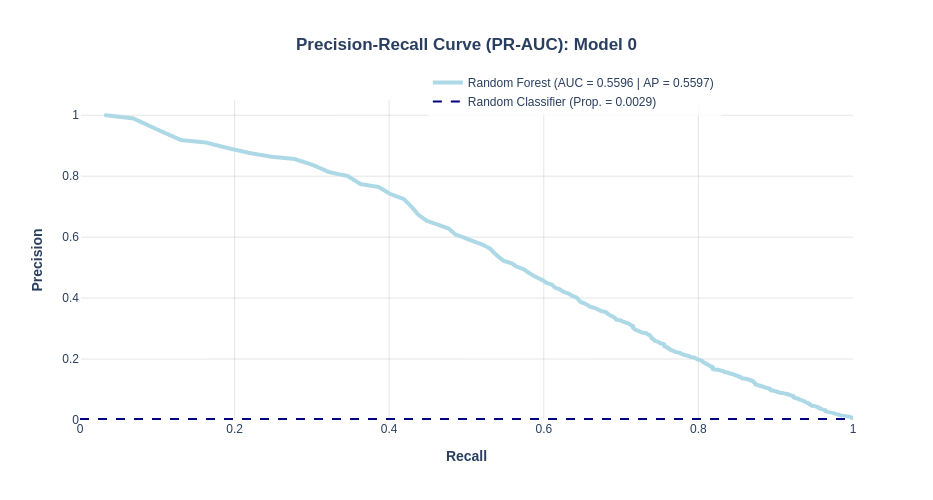

In [60]:
plot_PRAUC(precision_rf_0, recall_rf_0, pr_auc_rf_0, ap_rf_0, "Random Forest", "Model 0", "lightblue")

In [5]:
param_dist = {
    'n_estimators': [100, 300, 500],         
    'max_depth': [12, 16, 20, None],     
    'min_samples_split': [2, 5, 10],        
    'min_samples_leaf': [1, 2, 5],     
    'max_features': ['sqrt', 'log2', 0.3]
}

In [8]:
grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced", 
        random_state=777, 
        n_jobs=1  
    ),
    param_distributions=param_dist,
    n_iter=10,    
    cv=pds,
    scoring="average_precision", 
    verbose=0,  
    n_jobs=2,
    random_state=777
)

grid_search.fit(X_search, y_search)
best_rf_1 = grid_search.best_estimator_

print("--- BEST HYPERPARAMETERS FOUND ---")
print(grid_search.best_params_)

--- BEST HYPERPARAMETERS FOUND ---
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


In [9]:
test_probs_rf_1 = best_rf_1.predict_proba(X_test)[:, 1]
final_test_preds_rf_1 = test_probs_rf_1 > threshold
print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds_rf_1))

precision_rf_1, recall_rf_1, thresholds_rf_1 = precision_recall_curve(y_test, test_probs_rf_1)
pr_auc_rf_1 = auc(recall_rf_1, precision_rf_1)
ap_rf_1 = average_precision_score(y_test, test_probs_rf_1)
print(f"PR-AUC Score: {pr_auc_rf_1:.4f}")
print(f"Average Precision (AP) Score: {ap_rf_1:.4f}")

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    466815
           1       0.60      0.56      0.58      1377

    accuracy                           1.00    468192
   macro avg       0.80      0.78      0.79    468192
weighted avg       1.00      1.00      1.00    468192

PR-AUC Score: 0.6175
Average Precision (AP) Score: 0.6176


In [10]:
param_dist_rf_1 = {
    'n_estimators': [300],         
    'max_depth': [None],     
    'min_samples_split': [5],        
    'min_samples_leaf': [2],     
    'max_features': ['log2'],
    'bootstrap': [True, False],
    'criterion': ["gini", "entropy"],
}

grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=777, n_jobs=-1),
    param_distributions=param_dist_rf_1,
    n_iter=4,    
    cv=pds,
    scoring="average_precision", 
    verbose=0,  
    n_jobs=1,
    random_state=777
)

grid_search.fit(X_search, y_search)
best_rf_1 = grid_search.best_estimator_

print("--- BEST HYPERPARAMETERS FOUND ---")
print(grid_search.best_params_)

--- BEST HYPERPARAMETERS FOUND ---
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy', 'bootstrap': False}


In [23]:
# joblib.dump(best_rf_1, f"{path}mldl/ML_RandomForest_1.pkl")

In [16]:
test_probs_rf_1 = best_rf_1.predict_proba(X_test)[:, 1]
final_test_preds_rf_1 = test_probs_rf_1 > threshold
print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds_rf_1))

precision_rf_1, recall_rf_1, thresholds_rf_1 = precision_recall_curve(y_test, test_probs_rf_1)
pr_auc_rf_1 = auc(recall_rf_1, precision_rf_1)
ap_rf_1 = average_precision_score(y_test, test_probs_rf_1)
print(f"PR-AUC Score: {pr_auc_rf_1:.4f}")
print(f"Average Precision (AP) Score: {ap_rf_1:.4f}")

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    466815
           1       0.64      0.57      0.60      1377

    accuracy                           1.00    468192
   macro avg       0.82      0.78      0.80    468192
weighted avg       1.00      1.00      1.00    468192

PR-AUC Score: 0.6469
Average Precision (AP) Score: 0.6470


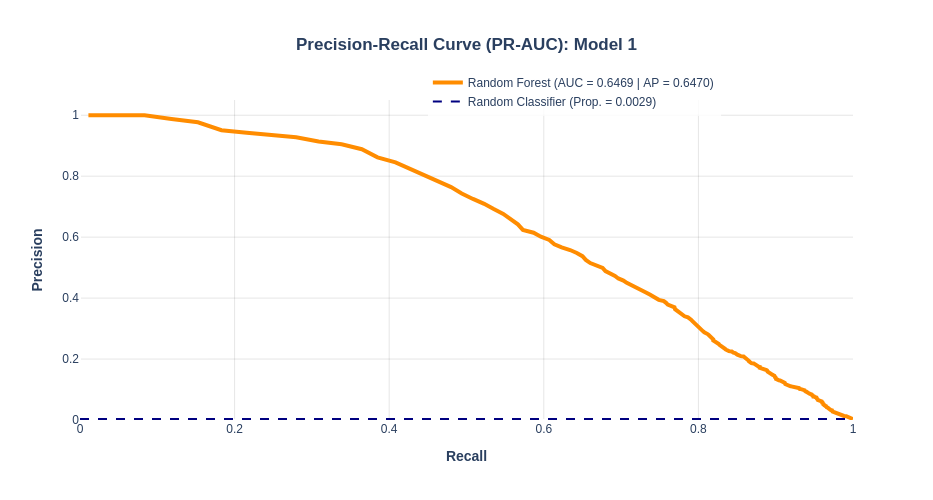

In [61]:
plot_PRAUC(precision_rf_1, recall_rf_1, pr_auc_rf_1, ap_rf_1, "Random Forest", "Model 1", "darkorange")

In [14]:
grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced", 
        random_state=777, 
        n_jobs=1  
    ),
    param_distributions=param_dist,
    n_iter=10,    
    cv=pds,
    scoring="f1", 
    verbose=0,  
    n_jobs=2,
    random_state=777
)

grid_search.fit(X_search, y_search)
best_rf_2 = grid_search.best_estimator_

print("--- BEST HYPERPARAMETERS FOUND ---")
print(grid_search.best_params_)

--- BEST HYPERPARAMETERS FOUND ---
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}


In [21]:
test_probs_rf_2 = best_rf_2.predict_proba(X_test)[:, 1]
final_test_preds_rf_2 = test_probs_rf_2 > threshold
print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds_rf_2))

precision_rf_2, recall_rf_2, thresholds_rf_2 = precision_recall_curve(y_test, test_probs_rf_2)
pr_auc_rf_2 = auc(recall_rf_2, precision_rf_2)
ap_rf_2 = average_precision_score(y_test, test_probs_rf_2)
print(f"PR-AUC Score: {pr_auc_rf_2:.4f}")
print(f"Average Precision (AP) Score: {ap_rf_2:.4f}")

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    466815
           1       0.60      0.56      0.58      1377

    accuracy                           1.00    468192
   macro avg       0.80      0.78      0.79    468192
weighted avg       1.00      1.00      1.00    468192

PR-AUC Score: 0.6175
Average Precision (AP) Score: 0.6176


In [25]:
param_dist_rf_2 = {
    'n_estimators': [300],         
    'max_depth': [None],     
    'min_samples_split': [5],        
    'min_samples_leaf': [2],     
    'max_features': ['log2'],
    'bootstrap': [True, False],
    'criterion': ["gini", "entropy"],
}

grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=777, n_jobs=-1),
    param_distributions=param_dist_rf_2,
    n_iter=4,    
    cv=pds,
    scoring="f1", 
    verbose=0,  
    n_jobs=1,
    random_state=777
)

grid_search.fit(X_search, y_search)
best_rf_2 = grid_search.best_estimator_

print("--- BEST HYPERPARAMETERS FOUND ---")
print(grid_search.best_params_)

--- BEST HYPERPARAMETERS FOUND ---
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None, 'criterion': 'entropy', 'bootstrap': True}


In [29]:
# joblib.dump(best_rf_2, f"{path}mldl/ML_RandomForest_2.pkl")

In [26]:
test_probs_rf_2 = best_rf_2.predict_proba(X_test)[:, 1]
final_test_preds_rf_2 = test_probs_rf_2 > threshold
print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds_rf_2))

precision_rf_2, recall_rf_2, thresholds_rf_2 = precision_recall_curve(y_test, test_probs_rf_2)
pr_auc_rf_2 = auc(recall_rf_2, precision_rf_2)
ap_rf_2 = average_precision_score(y_test, test_probs_rf_2)
print(f"PR-AUC Score: {pr_auc_rf_2:.4f}")
print(f"Average Precision (AP) Score: {ap_rf_2:.4f}")

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    466815
           1       0.66      0.55      0.60      1377

    accuracy                           1.00    468192
   macro avg       0.83      0.77      0.80    468192
weighted avg       1.00      1.00      1.00    468192

PR-AUC Score: 0.6364
Average Precision (AP) Score: 0.6365


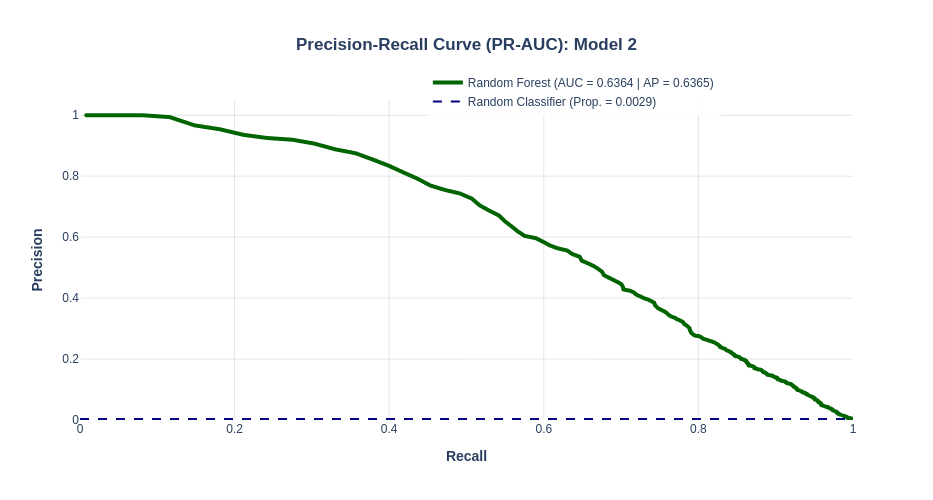

In [62]:
plot_PRAUC(precision_rf_2, recall_rf_2, pr_auc_rf_2, ap_rf_2, "Random Forest", "Model 2", "darkgreen")

XGBoost

In [9]:
num_legitimate = (y_train == 0).sum()
num_frauds = (y_train == 1).sum()
imbalance_weight = num_legitimate / num_frauds

param_dist_xgb = {
    'n_estimators': [200, 400, 600, 800],
    'max_depth': [3, 5, 7, 9],     
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    "min_child_weight": [1,3,5],
    "gamma": [0,0.2,0.5],
    "reg_alpha": [0,0.1,1],
    "reg_lambda": [1,2,5]
}

In [55]:
xgb_0 = xgb.XGBClassifier(
    n_estimators=300,        
    max_depth=6,               
    learning_rate=0.05,         
    scale_pos_weight=imbalance_weight,
    random_state=777,
    n_jobs=-1,                  
    eval_metric="logloss"       
)

xgb_0.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [65]:
# joblib.dump(xgb_model_0, f"{path}mldl/ML_XGBoost_0.pkl")

In [56]:
val_probs_xgb_0 = xgb_0.predict_proba(X_val)[:, 1]
calibrated_threshold = 0.45
calibrated_val_preds = val_probs_xgb_0 > calibrated_threshold
print("-------- VALIDATION REPORT --------")
print(classification_report(y_val, calibrated_val_preds))


precision_xgb_0, recall_xgb_0, thresholds_xgb_0 = precision_recall_curve(y_val, val_probs_xgb_0)
pr_auc_xgb_0 = auc(recall_xgb_0, precision_xgb_0)
ap_xgb_0 = average_precision_score(y_val, val_probs_xgb_0)
print(f"PR-AUC Score: {pr_auc_xgb_0:.4f}")
print(f"Average Precision (AP) Score: {ap_xgb_0:.4f}")

-------- VALIDATION REPORT --------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    466815
           1       0.11      0.94      0.20      1376

    accuracy                           0.98    468191
   macro avg       0.55      0.96      0.59    468191
weighted avg       1.00      0.98      0.99    468191

PR-AUC Score: 0.7210
Average Precision (AP) Score: 0.7211


In [57]:
test_probs_xgb_0 = xgb_0.predict_proba(X_test)[:, 1]
final_test_preds_xgb_0 = test_probs_xgb_0 > calibrated_threshold
print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds_xgb_0))

precision_xgb_0, recall_xgb_0, thresholds_xgb_0 = precision_recall_curve(y_test, test_probs_xgb_0)
pr_auc_xgb_0 = auc(recall_xgb_0, precision_xgb_0)
ap_xgb_0 = average_precision_score(y_test, test_probs_xgb_0)
print(f"PR-AUC Score: {pr_auc_xgb_0:.4f}")
print(f"Average Precision (AP) Score: {ap_xgb_0:.4f}")

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    466815
           1       0.11      0.94      0.19      1377

    accuracy                           0.98    468192
   macro avg       0.55      0.96      0.59    468192
weighted avg       1.00      0.98      0.99    468192

PR-AUC Score: 0.6922
Average Precision (AP) Score: 0.6923


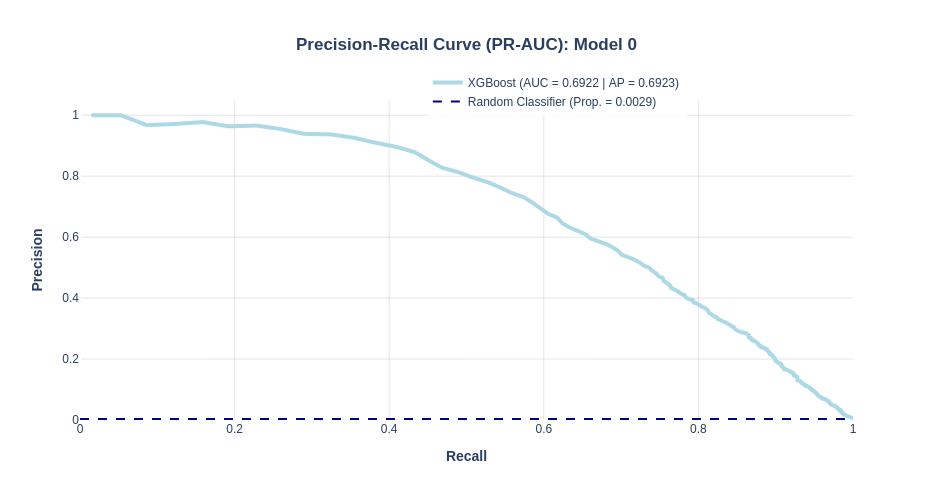

In [63]:
plot_PRAUC(precision_xgb_0, recall_xgb_0, pr_auc_xgb_0, ap_xgb_0, "XGBoost", "Model 0", "lightblue")

In [10]:
xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        scale_pos_weight=imbalance_weight,
        random_state=777,
        n_jobs=-1,
        eval_metric="logloss"
    ),
    param_distributions=param_dist_xgb,
    n_iter=5,                             
    cv=pds,                               
    scoring="average_precision",          
    verbose=0,
    n_jobs=1,
    random_state=777
)

xgb_search.fit(X_search, y_search)
best_xgb_1 = xgb_search.best_estimator_

print("--- BEST HYPERPARAMETERS FOUND ---")
print(xgb_search.best_params_)

--- BEST HYPERPARAMETERS FOUND ---
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.7}


In [79]:
# joblib.dump(best_xgb_1, f"{path}mldl/ML_XGBoost_1.pkl")

In [11]:
test_probs_xgb_1 = best_xgb_1.predict_proba(X_test)[:, 1]
final_test_preds_xgb_1 = test_probs_xgb_1 > calibrated_threshold
print("\n-------- FINAL TEST REPORT (XGBOOST) --------")
print(classification_report(y_test, final_test_preds_xgb_1))

precision_xgb_1, recall_xgb_1, thresholds_1 = precision_recall_curve(y_test, test_probs_xgb_1)
pr_auc_xgb_1 = auc(recall_xgb_1, precision_xgb_1)
ap_xgb_1 = average_precision_score(y_test, test_probs_xgb_1)
print(f"PR-AUC Score: {pr_auc_xgb_1:.4f}")
print(f"Average Precision (AP) Score: {ap_xgb_1:.4f}")


-------- FINAL TEST REPORT (XGBOOST) --------
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    466815
           1       0.31      0.89      0.46      1377

    accuracy                           0.99    468192
   macro avg       0.65      0.94      0.73    468192
weighted avg       1.00      0.99      1.00    468192

PR-AUC Score: 0.7697
Average Precision (AP) Score: 0.7697


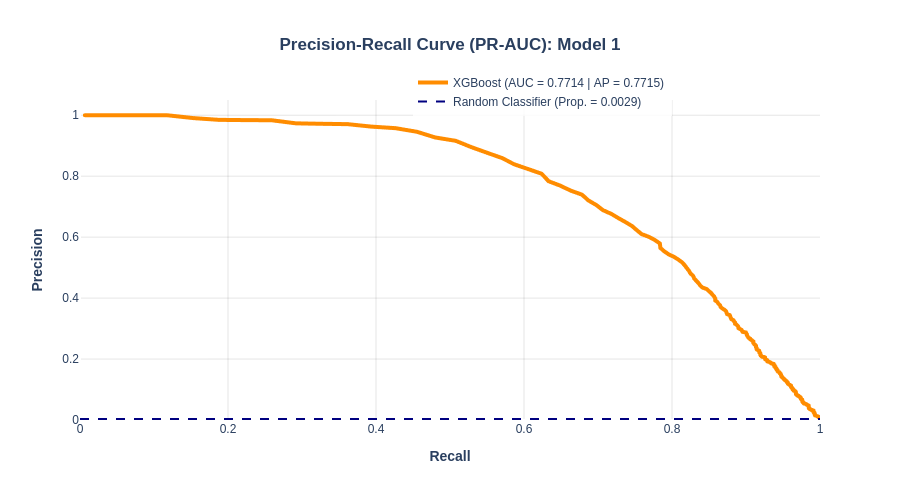

In [12]:
plot_PRAUC(precision_xgb_1, recall_xgb_1, pr_auc_xgb_1, ap_xgb_1, "XGBoost", "Model 1", "darkorange")

In [82]:
xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        scale_pos_weight=imbalance_weight,
        random_state=777,
        n_jobs=-1,
        eval_metric="logloss"
    ),
    param_distributions=param_dist_xgb,
    n_iter=5,                             
    cv=pds,                               
    scoring="f1",          
    verbose=0,
    n_jobs=1,
    random_state=777
)

xgb_search.fit(X_search, y_search)
best_xgb_2 = xgb_search.best_estimator_

print("--- BEST HYPERPARAMETERS FOUND ---")
print(xgb_search.best_params_)

--- BEST HYPERPARAMETERS FOUND ---
{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 1, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 0.7}


In [86]:
# joblib.dump(best_xgb_2, f"{path}mldl/ML_XGBoost_2.pkl")

In [83]:
test_probs_xgb_2 = best_xgb_2.predict_proba(X_test)[:, 1]
final_test_preds_xgb_2 = test_probs_xgb_2 > calibrated_threshold
print("-------- FINAL TEST REPORT (XGBOOST) --------")
print(classification_report(y_test, final_test_preds_xgb_2))

precision_xgb_2, recall_xgb_2, thresholds_2 = precision_recall_curve(y_test, test_probs_xgb_2)
pr_auc_xgb_2 = auc(recall_xgb_2, precision_xgb_2)
ap_xgb_2 = average_precision_score(y_test, test_probs_xgb_2)
print(f"PR-AUC Score: {pr_auc_xgb_2:.4f}")
print(f"Average Precision (AP) Score: {ap_xgb_2:.4f}")


-------- FINAL TEST REPORT (XGBOOST) --------
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    466815
           1       0.31      0.89      0.46      1377

    accuracy                           0.99    468192
   macro avg       0.66      0.94      0.73    468192
weighted avg       1.00      0.99      1.00    468192

PR-AUC Score: 0.7752
Average Precision (AP) Score: 0.7752


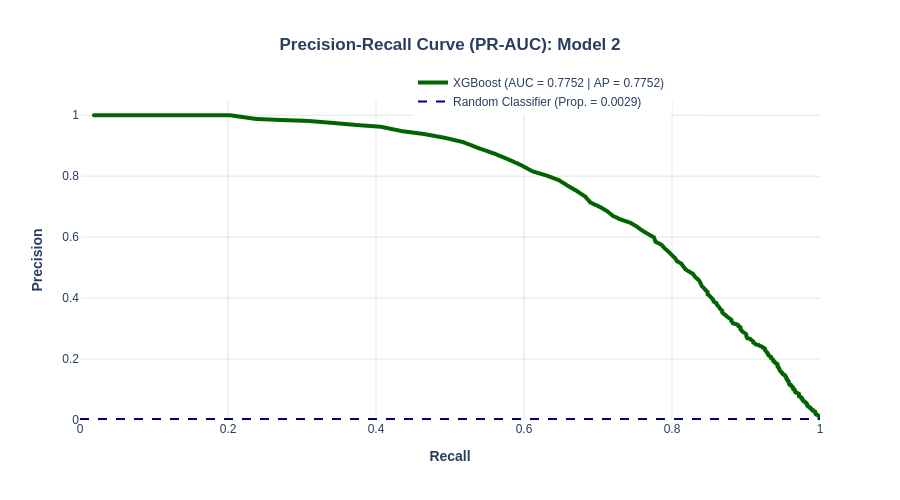

In [84]:
plot_PRAUC(precision_xgb_2, recall_xgb_2, pr_auc_xgb_2, ap_xgb_2, "XGBoost", "Model 2", "darkgreen")

LightGBM

In [5]:
lgb_param_dist = {
    'n_estimators': [200, 400, 600, 800],
    'num_leaves': [31, 63, 127, 255],    
    'learning_rate': [0.01, 0.05, 0.1],     
    'subsample': [0.7, 0.9, 1.0],           
    'colsample_bytree': [0.7, 0.9, 1.0], 
    'min_child_samples': [10, 20, 50]      
}

In [9]:
lgb_0 = lgb.LGBMClassifier(
    n_estimators=300,          
    num_leaves=31,             
    learning_rate=0.05,         
    scale_pos_weight=imbalance_weight,
    random_state=777,
    n_jobs=-1,                 
    verbosity=-1            
)

lgb_0.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [31]:
# joblib.dump(lgb_0, f"{path}mldl/ML_LightGBM_0.pkl")

In [10]:
val_probs_lgb_0 = lgb_0.predict_proba(X_val)[:, 1]
calibrated_threshold = 0.45
calibrated_val_preds = val_probs_lgb_0 > calibrated_threshold
print("-------- VALIDATION REPORT --------")
print(classification_report(y_val, calibrated_val_preds))


precision_lgb_0, recall_lgb_0, thresholds_lgb_0 = precision_recall_curve(y_val, val_probs_lgb_0)
pr_auc_lgb_0 = auc(recall_lgb_0, precision_lgb_0)
ap_lgb_0 = average_precision_score(y_val, val_probs_lgb_0)
print(f"PR-AUC Score: {pr_auc_lgb_0:.4f}")
print(f"Average Precision (AP) Score: {ap_lgb_0:.4f}")

-------- VALIDATION REPORT --------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    466815
           1       0.11      0.94      0.19      1376

    accuracy                           0.98    468191
   macro avg       0.55      0.96      0.59    468191
weighted avg       1.00      0.98      0.99    468191

PR-AUC Score: 0.7247
Average Precision (AP) Score: 0.7248


In [12]:
test_probs_lgb_0 = lgb_0.predict_proba(X_test)[:, 1]
final_test_preds_lgb_0 = test_probs_lgb_0 > calibrated_threshold
print("-------- FINAL TEST REPORT --------")
print(classification_report(y_test, final_test_preds_lgb_0))

precision_lgb_0, recall_lgb_0, thresholds_lgb_0 = precision_recall_curve(y_test, test_probs_lgb_0)
pr_auc_lgb_0 = auc(recall_lgb_0, precision_lgb_0)
ap_lgb_0 = average_precision_score(y_test, test_probs_lgb_0)
print(f"PR-AUC Score: {pr_auc_lgb_0:.4f}")
print(f"Average Precision (AP) Score: {ap_lgb_0:.4f}")

-------- FINAL TEST REPORT --------
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    466815
           1       0.11      0.95      0.19      1377

    accuracy                           0.98    468192
   macro avg       0.55      0.96      0.59    468192
weighted avg       1.00      0.98      0.99    468192

PR-AUC Score: 0.6999
Average Precision (AP) Score: 0.7000


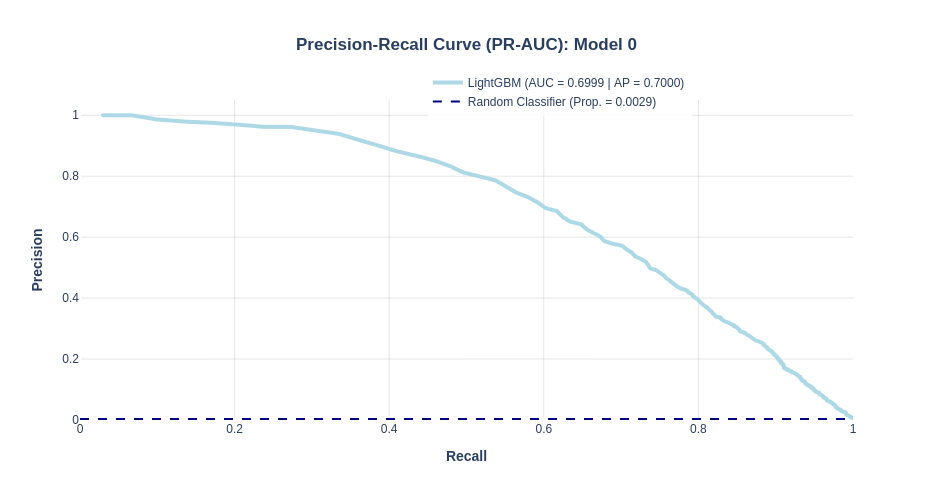

In [15]:
plot_PRAUC(precision_lgb_0, recall_lgb_0, pr_auc_lgb_0, ap_lgb_0, "LightGBM", "Model 0", "lightblue")

In [17]:
lgb_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(
        scale_pos_weight=imbalance_weight,  
        random_state=777,
        n_jobs=-1,
        verbosity=-1                        
    ),
    param_distributions=lgb_param_dist,
    n_iter=5,                               
    cv=pds,                                 
    scoring="average_precision",           
    verbose=0,
    n_jobs=1,
    random_state=77                               
)

lgb_search.fit(X_search, y_search)
best_lgb_1 = lgb_search.best_estimator_

print("--- BEST HYPERPARAMETERS FOUND (LIGHTGBM) ---")
print(lgb_search.best_params_)

--- BEST HYPERPARAMETERS FOUND (LIGHTGBM) ---
{'subsample': 0.9, 'num_leaves': 63, 'n_estimators': 400, 'min_child_samples': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


In [28]:
# joblib.dump(best_lgb_1, f"{path}mldl/ML_LightGBM_1.pkl")

In [19]:
test_probs_lgb_1 = best_lgb_1.predict_proba(X_test)[:, 1]
final_test_preds_lgb_1 = test_probs_lgb_1 > calibrated_threshold
print("-------- FINAL TEST REPORT (LIGHTGBM) --------")
print(classification_report(y_test, final_test_preds_lgb_1))

precision_lgb_1, recall_lgb_1, thresholds_1 = precision_recall_curve(y_test, test_probs_lgb_1)
pr_auc_lgb_1 = auc(recall_lgb_1, precision_lgb_1)
ap_lgb_1 = average_precision_score(y_test, test_probs_lgb_1)
print(f"PR-AUC Score: {pr_auc_lgb_1:.4f}")
print(f"Average Precision (AP) Score: {ap_lgb_1:.4f}")

-------- FINAL TEST REPORT (LIGHTGBM) --------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    466815
           1       0.39      0.84      0.53      1377

    accuracy                           1.00    468192
   macro avg       0.69      0.92      0.76    468192
weighted avg       1.00      1.00      1.00    468192

PR-AUC Score: 0.7167
Average Precision (AP) Score: 0.7171


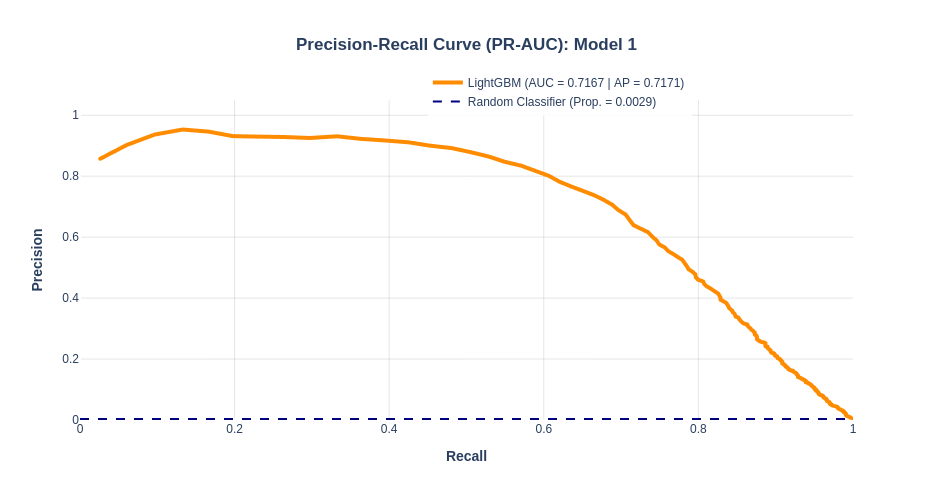

In [20]:
plot_PRAUC(precision_lgb_1, recall_lgb_1, pr_auc_lgb_1, ap_lgb_1, "LightGBM", "Model 1", "darkorange")

In [21]:
lgb_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(
        scale_pos_weight=imbalance_weight,  
        random_state=777,
        n_jobs=-1,
        verbosity=-1                        
    ),
    param_distributions=lgb_param_dist,
    n_iter=5,                               
    cv=pds,                                 
    scoring="f1",           
    verbose=0,
    n_jobs=1,
    random_state=77                               
)

lgb_search.fit(X_search, y_search)
best_lgb_2 = lgb_search.best_estimator_

print("--- BEST HYPERPARAMETERS FOUND (LIGHTGBM) ---")
print(lgb_search.best_params_)

--- BEST HYPERPARAMETERS FOUND (LIGHTGBM) ---
{'subsample': 0.9, 'num_leaves': 127, 'n_estimators': 800, 'min_child_samples': 20, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


In [26]:
# joblib.dump(best_lgb_2, f"{path}mldl/ML_LightGBM_2.pkl")

In [22]:
test_probs_lgb_2 = best_lgb_2.predict_proba(X_test)[:, 1]
final_test_preds_lgb_2 = test_probs_lgb_2 > calibrated_threshold
print("-------- FINAL TEST REPORT (LIGHTGBM) --------")
print(classification_report(y_test, final_test_preds_lgb_2))

precision_lgb_2, recall_lgb_2, thresholds_2 = precision_recall_curve(y_test, test_probs_lgb_2)
pr_auc_lgb_2 = auc(recall_lgb_2, precision_lgb_2)
ap_lgb_2 = average_precision_score(y_test, test_probs_lgb_2)
print(f"PR-AUC Score: {pr_auc_lgb_2:.4f}")
print(f"Average Precision (AP) Score: {ap_lgb_2:.4f}")

-------- FINAL TEST REPORT (LIGHTGBM) --------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    466815
           1       0.54      0.81      0.65      1377

    accuracy                           1.00    468192
   macro avg       0.77      0.90      0.82    468192
weighted avg       1.00      1.00      1.00    468192

PR-AUC Score: 0.7896
Average Precision (AP) Score: 0.7896


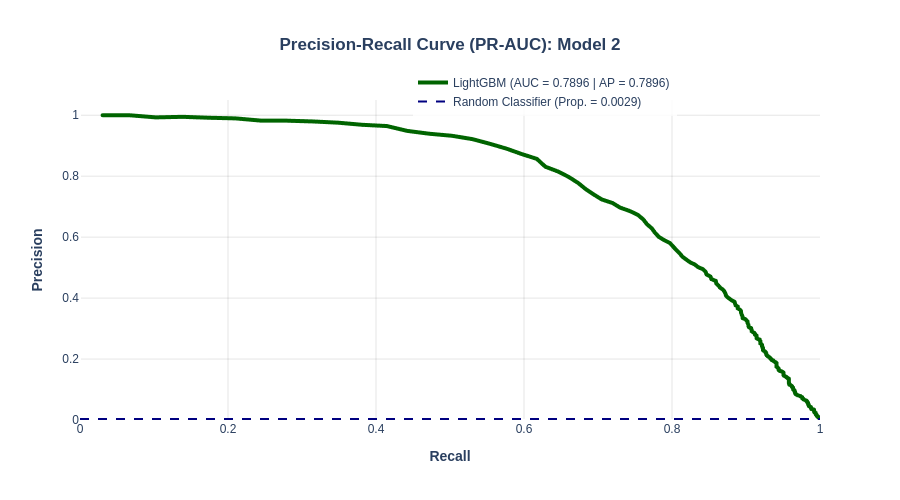

In [24]:
plot_PRAUC(precision_lgb_2, recall_lgb_2, pr_auc_lgb_2, ap_lgb_2, "LightGBM", "Model 2", "darkgreen")